In [1]:
library(Seurat)

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.2”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [2]:
all_cor <- readRDS("../output/07-all_correlations_20251030.rds")

In [3]:
head(all_cor);dim(all_cor);all_cor

chrom100k,correlation,Group
<chr>,<dbl>,<fct>
chr1_100,0.2180242,5hmCG
chr1_1000,0.2593081,5hmCG
chr1_1001,0.2795819,5hmCG
chr1_1002,0.2828362,5hmCG
chr1_1003,0.3068630,5hmCG
chr1_1004,0.3060237,5hmCG


[1] 144191      3

chrom100k,correlation,Group
<chr>,<dbl>,<fct>
chr1_100,0.21802421,5hmCG
chr1_1000,0.25930814,5hmCG
chr1_1001,0.27958191,5hmCG
chr1_1002,0.28283620,5hmCG
chr1_1003,0.30686297,5hmCG
chr1_1004,0.30602371,5hmCG
chr1_1005,0.17528066,5hmCG
chr1_1006,0.24865629,5hmCG
chr1_1007,0.17084597,5hmCG


In [4]:
all_cor[all_cor$chrom100k == "chr2_68",]

chrom100k,correlation,Group
<chr>,<dbl>,<fct>
chr2_68,-0.7647073,5hmCG
chr2_68,-0.7034576,5hmCG+5mCG
chr2_68,-0.5397603,5mCG
chr2_68,0.3752511,5hmCH
chr2_68,-0.5340970,5hmCH+5mCH
chr2_68,-0.4367122,5mCH


In [5]:
library(tidyr)

In [6]:
all_cor_wide <- all_cor %>%
  pivot_wider(names_from = Group,
              values_from = correlation)

In [7]:
head(all_cor_wide);dim(all_cor_wide)

chrom100k,5hmCG,5hmCG+5mCG,5mCG,5hmCH,5hmCH+5mCH,5mCH
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_100,0.2180242,0.55725284,0.03328609,-0.01770574,0.4674562,0.49735520
chr1_1000,0.2593081,-0.04196998,-0.27148129,0.40288868,0.0929683,-0.04306985
chr1_1001,0.2795819,0.07441743,-0.24346956,0.62557656,0.1171030,-0.04316301
chr1_1002,0.2828362,-0.05400766,-0.32369290,0.52481323,0.1551744,0.02752212
chr1_1003,0.3068630,-0.06728852,-0.37181961,0.41683918,0.2428178,0.12512783
chr1_1004,0.3060237,-0.14099020,-0.36655618,0.57369431,0.2055008,0.10388973


[1] 24032     7

In [8]:
library(ggplot2)

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The dot-dot notation (`..level..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(level)` instead.”
Warning message:
“Removed 296 rows containing non-finite outside the scale range (`stat_density2d()`).”
Warning message:
“Removed 296 rows containing missing values or values outside the scale range (`geom_point()`).”


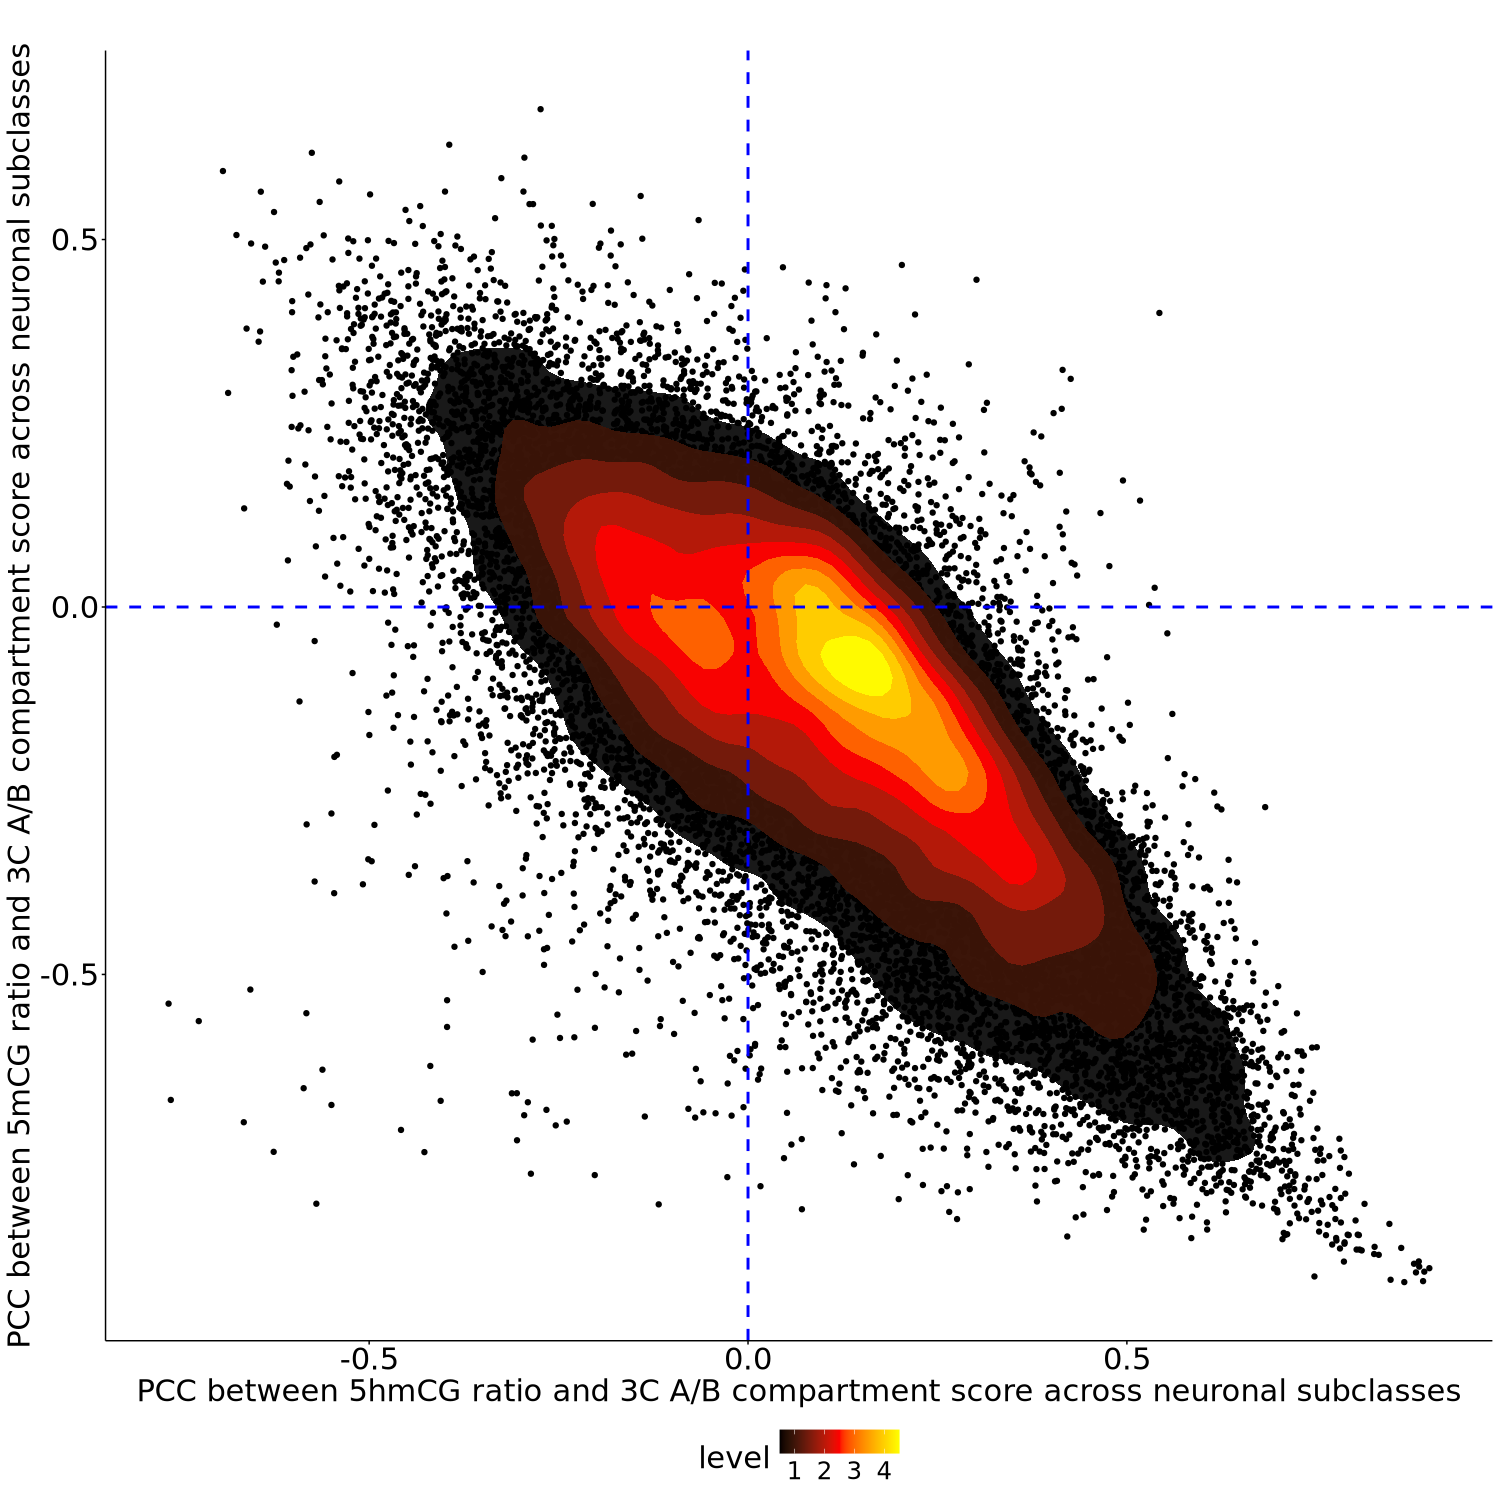

In [9]:
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 100)
ggplot(all_cor_wide, aes(x = `5hmCG`, y = `5mCG`)) +
  geom_point(color = "black", alpha = 1, size = 1.5) +
  stat_density_2d(aes(fill = ..level..), geom = "polygon", alpha = 0.9, 
                  h = c(0.1, 0.1), n = 100) +
  scale_fill_gradientn(colors = c("black", "red", "yellow")) +
#   geom_smooth(method = "loess", se = FALSE, color = "purple", size = 1.5) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "blue", size = 1) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "blue", size = 1) +
  labs(x = "PCC between 5hmCG ratio and 3C A/B compartment score across neuronal subclasses", 
       y = "PCC between 5mCG ratio and 3C A/B compartment score across neuronal subclasses", title = "") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    axis.text.x = element_text(size = 22),
    axis.text.y = element_text(size = 22),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    legend.position = "bottom",
    text = element_text(size = 22)
  )

In [10]:
# merged_df_max_5hmCG <- readRDS("../output/10-merged_df_max_5hmCG_neuron_and_non_neuron.rds")
merged_df_top100_5hmCG <- readRDS("../output/07-merged_df_top100_3C_5hmCG_neuron.rds")

In [11]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘dplyr’ was built under R version 4.3.2”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [12]:
# rownames(merged_df_top100_5hmCG) <- NULL
# merged_df_top100_5hmCG <- merged_df_top100_5hmCG %>% column_to_rownames("chrom100k")
merged_df_seleted <- merged_df_top100_5hmCG[c('chr7_903','chr5_201','chr2_390','chr8_173','chr8_171','chr8_172'),]

In [13]:
merged_df_seleted

,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr7_903,1.7105392,2.856917,3.512898,3.734948,0.1778226,0.7659773,2.959611,2.4189963,4.824448,1.0355546,⋯,3.7674706,4.258552,3.786138,-0.5911002,0.1942439,-0.6029984,-6.747073,10.146478,-1.014756,8.945236
chr5_201,-5.6518192,1.488893,4.314856,2.253393,-3.3966491,-8.9408312,5.053926,-0.1388017,6.124374,-2.0613821,⋯,-4.4319019,3.718318,3.858795,-10.0667868,-9.6159811,-1.6083663,-15.047481,13.807653,-8.250319,-18.941586
chr2_390,0.5715855,5.248351,9.250517,5.509477,2.3050508,3.1103320,6.645447,6.1526594,8.878694,0.2993077,⋯,5.6781569,8.586951,5.509015,-3.7940540,-2.6354773,3.9414859,-7.530856,1.247645,2.019559,8.614120
chr8_173,7.7219462,7.193171,6.914012,8.559134,3.3013599,8.6305733,6.068660,1.9922826,7.413206,5.8130345,⋯,-2.2676432,6.207729,6.206310,7.5312934,6.0488334,3.6594610,-12.860137,-10.633036,14.279561,-18.813234
chr8_171,9.8715839,9.741956,9.032305,10.856374,4.5272808,9.4130058,8.787358,2.8193302,8.723046,7.0606318,⋯,-0.3049224,9.329975,8.034087,9.2162485,8.3411188,3.3317077,-12.178854,-12.419855,15.506176,-18.920788
chr8_172,8.2225485,7.956738,7.734872,9.483785,3.4254150,8.7106237,7.306526,2.4553394,7.988753,6.1674099,⋯,-1.1946702,7.529195,7.132567,8.1473866,7.0011683,3.5897856,-12.734256,-12.289319,15.034841,-18.901043


In [ ]:
seuratObj <- readRDS("../../01.RNA-integration/04.Joint-Cabernet.Zeng_10X_RNA.integration/Joint_Cabernet.with_celltype.rds")

In [15]:
head(seuratObj@meta.data);dim(seuratObj)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.0.8,seurat_clusters,SCT_snn_res.1.8,class_label,⋯,subclass.annotated_all,class_label_once,subclass_label_once,major_class.once,subclass.once,SampleID,three_class,Region,Brain_Region,Neuron_non_neuron
,<fct>,<dbl>,<int>,<dbl>,<dbl>,<int>,<fct>,<fct>,<fct>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AACCAGAG,P49,211045,1842,0,177044,1830,4,3,3,IT-ET Glut,⋯,CA1-ProS Glut,IT-ET Glut,CA1-ProS Glut,IT-ET Glut,CA1-ProS Glut,P49_Male_Hippo_TSO_RNA_plate1.AACCAGAG,Exc,Hippo,Hippo,Neuron
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AAGACACC,P49,138009,1722,0,176396,1718,20,32,32,IT-ET Glut,⋯,SUB-ProS Glut,IT-ET Glut,SUB-ProS Glut,IT-ET Glut,SUB-ProS Glut,P49_Male_Hippo_TSO_RNA_plate1.AAGACACC,Exc,Hippo,Hippo,Neuron
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AAGACCGT,P49,233802,2482,0,177163,2461,4,3,3,IT-ET Glut,⋯,CA1-ProS Glut,IT-ET Glut,CA1-ProS Glut,IT-ET Glut,CA1-ProS Glut,P49_Male_Hippo_TSO_RNA_plate1.AAGACCGT,Exc,Hippo,Hippo,Neuron
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AGACCTTG,P49,231554,2659,0,177237,2631,20,32,32,IT-ET Glut,⋯,SUB-ProS Glut,IT-ET Glut,SUB-ProS Glut,IT-ET Glut,L5 ET CTX Glut,P49_Male_Hippo_TSO_RNA_plate1.AGACCTTG,Exc,Hippo,Hippo,Neuron
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AGACGCTA,P49,213921,2202,0,176990,2182,4,18,18,IT-ET Glut,⋯,CA1-ProS Glut,IT-ET Glut,SUB-ProS Glut,IT-ET Glut,CA1-ProS Glut,P49_Male_Hippo_TSO_RNA_plate1.AGACGCTA,Exc,Hippo,Hippo,Neuron
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AGCCTATC,P49,142882,1849,0,176263,1835,24,23,23,CTX-CGE GABA,⋯,Sncg Gaba,CTX-CGE GABA,Lamp5 Gaba,CTX-CGE GABA,Vip Gaba,P49_Male_Hippo_TSO_RNA_plate1.AGCCTATC,Inh,Hippo,Hippo,Neuron


[1] 40739 44689

In [16]:
UMAP <- data.frame(Embeddings(seuratObj, reduction = 'umap')[Cells(seuratObj),])
head(UMAP);dim(UMAP)

,umap_1,umap_2
,<dbl>,<dbl>
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AACCAGAG,-2.923547,14.4602646
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AAGACACC,-4.796560,11.2587418
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AAGACCGT,-3.454821,14.5074591
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AGACCTTG,-5.147426,10.8200507
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AGACGCTA,-3.851346,13.5682282
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AGCCTATC,3.895295,0.1613024


[1] 44689     2

In [17]:
rownames(UMAP) = unlist(lapply(rownames(UMAP), function(x) strsplit(x,'Cabernet@@_')[[1]][2]))
head(UMAP);dim(UMAP)

,umap_1,umap_2
,<dbl>,<dbl>
P49_Male_Hippo_TSO_RNA_plate1.AACCAGAG,-2.923547,14.4602646
P49_Male_Hippo_TSO_RNA_plate1.AAGACACC,-4.796560,11.2587418
P49_Male_Hippo_TSO_RNA_plate1.AAGACCGT,-3.454821,14.5074591
P49_Male_Hippo_TSO_RNA_plate1.AGACCTTG,-5.147426,10.8200507
P49_Male_Hippo_TSO_RNA_plate1.AGACGCTA,-3.851346,13.5682282
P49_Male_Hippo_TSO_RNA_plate1.AGCCTATC,3.895295,0.1613024


[1] 44689     2

In [ ]:
paired_sampleinfo = read.csv("../../../03.data/02.metainfo/01.Young_Mouse/RNA_DNA_match_name_QC_class_label_young.csv",header =T)
head(paired_sampleinfo);dim(paired_sampleinfo)

,unique_id,hmC_SampleID,hmC_QC,mC_SampleID,mC_QC,RNA_SampleID,RNA_QC,total_QC,class_label,subclass_label,three_class,Region,Brain_Region,Neuron_non_neuron
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,P49_Male_Hippo_plate1.AACCAGAG,P49_Male_Hippo_TSO_joint5hmC_plate1.AACCAGAG,1,P49_Male_Hippo_TSO_joint5mC_plate1.AACCAGAG,0,P49_Male_Hippo_TSO_RNA_plate1.AACCAGAG,1,0,IT-ET Glut,CA1-ProS Glut,Exc,Hippo,Hippo,Neuron
2,P49_Male_Hippo_plate1.AAGACACC,P49_Male_Hippo_TSO_joint5hmC_plate1.AAGACACC,1,P49_Male_Hippo_TSO_joint5mC_plate1.AAGACACC,0,P49_Male_Hippo_TSO_RNA_plate1.AAGACACC,1,0,IT-ET Glut,SUB-ProS Glut,Exc,Hippo,Hippo,Neuron
3,P49_Male_Hippo_plate1.AAGACCGT,P49_Male_Hippo_TSO_joint5hmC_plate1.AAGACCGT,1,P49_Male_Hippo_TSO_joint5mC_plate1.AAGACCGT,0,P49_Male_Hippo_TSO_RNA_plate1.AAGACCGT,1,0,IT-ET Glut,CA1-ProS Glut,Exc,Hippo,Hippo,Neuron
4,P49_Male_Hippo_plate1.AGACCTTG,P49_Male_Hippo_TSO_joint5hmC_plate1.AGACCTTG,1,P49_Male_Hippo_TSO_joint5mC_plate1.AGACCTTG,0,P49_Male_Hippo_TSO_RNA_plate1.AGACCTTG,1,0,IT-ET Glut,SUB-ProS Glut,Exc,Hippo,Hippo,Neuron
5,P49_Male_Hippo_plate1.AGACGCTA,P49_Male_Hippo_TSO_joint5hmC_plate1.AGACGCTA,1,P49_Male_Hippo_TSO_joint5mC_plate1.AGACGCTA,0,P49_Male_Hippo_TSO_RNA_plate1.AGACGCTA,1,0,IT-ET Glut,CA1-ProS Glut,Exc,Hippo,Hippo,Neuron
6,P49_Male_Hippo_plate1.AGCCTATC,P49_Male_Hippo_TSO_joint5hmC_plate1.AGCCTATC,1,P49_Male_Hippo_TSO_joint5mC_plate1.AGCCTATC,0,P49_Male_Hippo_TSO_RNA_plate1.AGCCTATC,1,0,CTX-CGE GABA,Sncg Gaba,Inh,Hippo,Hippo,Neuron


[1] 47712    14

In [19]:
paired_sampleinfo <- paired_sampleinfo[paired_sampleinfo$total_QC == 1,]
head(paired_sampleinfo);dim(paired_sampleinfo)

,unique_id,hmC_SampleID,hmC_QC,mC_SampleID,mC_QC,RNA_SampleID,RNA_QC,total_QC,class_label,subclass_label,three_class,Region,Brain_Region,Neuron_non_neuron
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1153,P49_Male_LeftCortex_plate1.AACCAGAG,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AACCAGAG,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AACCAGAG,1,P49_Male_LeftCortex_TSO_RNA_plate1.AACCAGAG,1,1,IT-ET Glut,L4/5 IT CTX Glut,Exc,LeftCortex,Cortex,Neuron
1154,P49_Male_LeftCortex_plate1.AAGACACC,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AAGACACC,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AAGACACC,1,P49_Male_LeftCortex_TSO_RNA_plate1.AAGACACC,1,1,IT-ET Glut,CLA-EPd-CTX Car3 Glut,Exc,LeftCortex,Cortex,Neuron
1155,P49_Male_LeftCortex_plate1.AAGACCGT,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AAGACCGT,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AAGACCGT,1,P49_Male_LeftCortex_TSO_RNA_plate1.AAGACCGT,1,1,IT-ET Glut,L4 RSP-ACA Glut,Exc,LeftCortex,Cortex,Neuron
1156,P49_Male_LeftCortex_plate1.AGACCTTG,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AGACCTTG,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AGACCTTG,1,P49_Male_LeftCortex_TSO_RNA_plate1.AGACCTTG,1,1,NP-CT-L6b Glut,L6 CT CTX Glut,Exc,LeftCortex,Cortex,Neuron
1157,P49_Male_LeftCortex_plate1.AGACGCTA,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AGACGCTA,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AGACGCTA,1,P49_Male_LeftCortex_TSO_RNA_plate1.AGACGCTA,1,1,IT-ET Glut,L4/5 IT CTX Glut,Exc,LeftCortex,Cortex,Neuron
1158,P49_Male_LeftCortex_plate1.AGCCTATC,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AGCCTATC,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AGCCTATC,1,P49_Male_LeftCortex_TSO_RNA_plate1.AGCCTATC,1,1,IT-ET Glut,L2/3 IT RSP Glut,Exc,LeftCortex,Cortex,Neuron


[1] 43075    14

In [20]:
table(rownames(UMAP) %in% paired_sampleinfo$RNA_SampleID)


FALSE  TRUE 
 1614 43075 

In [21]:
UMAP <- UMAP[rownames(UMAP) %in% paired_sampleinfo$RNA_SampleID,]
head(UMAP);dim(UMAP)

,umap_1,umap_2
,<dbl>,<dbl>
P49_Male_LeftCortex_TSO_RNA_plate1.AACCAGAG,-6.1215079,-7.1530786
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACACC,0.3499541,-2.9416876
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACCGT,-7.2109806,0.2295699
P49_Male_LeftCortex_TSO_RNA_plate1.AGACCTTG,-1.3848886,-13.3449722
P49_Male_LeftCortex_TSO_RNA_plate1.AGACGCTA,-6.2881157,-7.7277642
P49_Male_LeftCortex_TSO_RNA_plate1.AGCCTATC,-7.8770611,-2.0938309


[1] 43075     2

In [22]:
UMAP$subclass <- paired_sampleinfo$subclass_label[match(rownames(UMAP),paired_sampleinfo$RNA_SampleID)]

In [23]:
head(UMAP);dim(UMAP)

,umap_1,umap_2,subclass
,<dbl>,<dbl>,<chr>
P49_Male_LeftCortex_TSO_RNA_plate1.AACCAGAG,-6.1215079,-7.1530786,L4/5 IT CTX Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACACC,0.3499541,-2.9416876,CLA-EPd-CTX Car3 Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACCGT,-7.2109806,0.2295699,L4 RSP-ACA Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AGACCTTG,-1.3848886,-13.3449722,L6 CT CTX Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AGACGCTA,-6.2881157,-7.7277642,L4/5 IT CTX Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AGCCTATC,-7.8770611,-2.0938309,L2/3 IT RSP Glut


[1] 43075     3

In [24]:
unique(UMAP$subclass)

[1] "L4/5 IT CTX Glut"      "CLA-EPd-CTX Car3 Glut" "L4 RSP-ACA Glut"      
 [4] "L6 CT CTX Glut"        "L2/3 IT RSP Glut"      "L2/3 IT CTX Glut"     
 [7] "IT AON-TT-DP Glut"     "Astro-TE NN"           "Microglia NN"         
[10] "Oligo NN"              "STR D1 Gaba"           "L5 IT CTX Glut"       
[13] "L6 IT CTX Glut"        "L5 NP CTX Glut"        "DG Glut"              
[16] "Pvalb Gaba"            "L5 ET CTX Glut"        "Sncg Gaba"            
[19] "Lamp5 Gaba"            "OEC NN"                "Sst Gaba"             
[22] "ACB-BST-FS D1 Gaba"    "OPC NN"                "CA1-ProS Glut"        
[25] "OB-in Frmd7 Gaba"      "CA3 Glut"              "SUB-ProS Glut"        
[28] "OB Eomes Ms4a15 Glut"  "OB-out Frmd7 Gaba"     "STR D2 Gaba"          
[31] "LA-BLA-BMA-PA Glut"

In [25]:
# UMAP <- UMAP[!UMAP$subclass %in% c('Astro-TE NN','Microglia NN','Oligo NN','OPC NN','OEC NN'),]
UMAP <- UMAP[!UMAP$subclass %in% c('OEC NN'),]

In [26]:
library(dplyr)

In [27]:
merged_df_max_3C <- merged_df_seleted
merged_df_max_3C

,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr7_903,1.7105392,2.856917,3.512898,3.734948,0.1778226,0.7659773,2.959611,2.4189963,4.824448,1.0355546,⋯,3.7674706,4.258552,3.786138,-0.5911002,0.1942439,-0.6029984,-6.747073,10.146478,-1.014756,8.945236
chr5_201,-5.6518192,1.488893,4.314856,2.253393,-3.3966491,-8.9408312,5.053926,-0.1388017,6.124374,-2.0613821,⋯,-4.4319019,3.718318,3.858795,-10.0667868,-9.6159811,-1.6083663,-15.047481,13.807653,-8.250319,-18.941586
chr2_390,0.5715855,5.248351,9.250517,5.509477,2.3050508,3.1103320,6.645447,6.1526594,8.878694,0.2993077,⋯,5.6781569,8.586951,5.509015,-3.7940540,-2.6354773,3.9414859,-7.530856,1.247645,2.019559,8.614120
chr8_173,7.7219462,7.193171,6.914012,8.559134,3.3013599,8.6305733,6.068660,1.9922826,7.413206,5.8130345,⋯,-2.2676432,6.207729,6.206310,7.5312934,6.0488334,3.6594610,-12.860137,-10.633036,14.279561,-18.813234
chr8_171,9.8715839,9.741956,9.032305,10.856374,4.5272808,9.4130058,8.787358,2.8193302,8.723046,7.0606318,⋯,-0.3049224,9.329975,8.034087,9.2162485,8.3411188,3.3317077,-12.178854,-12.419855,15.506176,-18.920788
chr8_172,8.2225485,7.956738,7.734872,9.483785,3.4254150,8.7106237,7.306526,2.4553394,7.988753,6.1674099,⋯,-1.1946702,7.529195,7.132567,8.1473866,7.0011683,3.5897856,-12.734256,-12.289319,15.034841,-18.901043


In [28]:
head(UMAP);dim(UMAP)

,umap_1,umap_2,subclass
,<dbl>,<dbl>,<chr>
P49_Male_LeftCortex_TSO_RNA_plate1.AACCAGAG,-6.1215079,-7.1530786,L4/5 IT CTX Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACACC,0.3499541,-2.9416876,CLA-EPd-CTX Car3 Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACCGT,-7.2109806,0.2295699,L4 RSP-ACA Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AGACCTTG,-1.3848886,-13.3449722,L6 CT CTX Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AGACGCTA,-6.2881157,-7.7277642,L4/5 IT CTX Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AGCCTATC,-7.8770611,-2.0938309,L2/3 IT RSP Glut


[1] 42841     3

In [29]:
UMAP_filter <- UMAP[!UMAP$subclass %in% "OEC NN",]

In [30]:
head(UMAP_filter);dim(UMAP_filter)

,umap_1,umap_2,subclass
,<dbl>,<dbl>,<chr>
P49_Male_LeftCortex_TSO_RNA_plate1.AACCAGAG,-6.1215079,-7.1530786,L4/5 IT CTX Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACACC,0.3499541,-2.9416876,CLA-EPd-CTX Car3 Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACCGT,-7.2109806,0.2295699,L4 RSP-ACA Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AGACCTTG,-1.3848886,-13.3449722,L6 CT CTX Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AGACGCTA,-6.2881157,-7.7277642,L4/5 IT CTX Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AGCCTATC,-7.8770611,-2.0938309,L2/3 IT RSP Glut


[1] 42841     3

In [31]:
merged_df_max_3C_t <- merged_df_max_3C %>% t()

In [32]:
merged_df_max_3C_t <- merged_df_max_3C_t %>% data.frame()

In [33]:
merged_df_max_3C_t

,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
L2/3 IT CTX Glut,1.7105392,-5.6518192,0.5715855,7.7219462,9.8715839,8.2225485
L4/5 IT CTX Glut,2.8569169,1.4888928,5.2483511,7.1931705,9.7419558,7.9567375
L5 IT CTX Glut,3.5128977,4.3148556,9.2505169,6.9140124,9.0323048,7.7348723
L6 IT CTX Glut,3.7349477,2.2533934,5.5094771,8.5591335,10.8563738,9.4837847
IT AON-TT-DP Glut,0.1778226,-3.3966491,2.3050508,3.3013599,4.5272808,3.4254150
LA-BLA-BMA-PA Glut,0.7659773,-8.9408312,3.1103320,8.6305733,9.4130058,8.7106237
L2/3 IT RSP Glut,2.9596107,5.0539260,6.6454468,6.0686598,8.7873583,7.3065262
L4 RSP-ACA Glut,2.4189963,-0.1388017,6.1526594,1.9922826,2.8193302,2.4553394
L5 ET CTX Glut,4.8244476,6.1243739,8.8786936,7.4132056,8.7230463,7.9887533


In [35]:
table(UMAP_filter$subclass %in% rownames(merged_df_max_3C_t))


 TRUE 
42841 

In [36]:
head(UMAP_filter);dim(UMAP_filter)

,umap_1,umap_2,subclass
,<dbl>,<dbl>,<chr>
P49_Male_LeftCortex_TSO_RNA_plate1.AACCAGAG,-6.1215079,-7.1530786,L4/5 IT CTX Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACACC,0.3499541,-2.9416876,CLA-EPd-CTX Car3 Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACCGT,-7.2109806,0.2295699,L4 RSP-ACA Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AGACCTTG,-1.3848886,-13.3449722,L6 CT CTX Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AGACGCTA,-6.2881157,-7.7277642,L4/5 IT CTX Glut
P49_Male_LeftCortex_TSO_RNA_plate1.AGCCTATC,-7.8770611,-2.0938309,L2/3 IT RSP Glut


[1] 42841     3

In [37]:
merged_df_max_3C_t_aaa <- merged_df_max_3C_t %>%
  tibble::rownames_to_column("subclass")

In [38]:
merged_df_max_3C_t_aaa

subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
L2/3 IT CTX Glut,1.7105392,-5.6518192,0.5715855,7.7219462,9.8715839,8.2225485
L4/5 IT CTX Glut,2.8569169,1.4888928,5.2483511,7.1931705,9.7419558,7.9567375
L5 IT CTX Glut,3.5128977,4.3148556,9.2505169,6.9140124,9.0323048,7.7348723
L6 IT CTX Glut,3.7349477,2.2533934,5.5094771,8.5591335,10.8563738,9.4837847
IT AON-TT-DP Glut,0.1778226,-3.3966491,2.3050508,3.3013599,4.5272808,3.4254150
LA-BLA-BMA-PA Glut,0.7659773,-8.9408312,3.1103320,8.6305733,9.4130058,8.7106237
L2/3 IT RSP Glut,2.9596107,5.0539260,6.6454468,6.0686598,8.7873583,7.3065262
L4 RSP-ACA Glut,2.4189963,-0.1388017,6.1526594,1.9922826,2.8193302,2.4553394
L5 ET CTX Glut,4.8244476,6.1243739,8.8786936,7.4132056,8.7230463,7.9887533


In [39]:
UMAP_filter_merged <- UMAP_filter %>%
  left_join(merged_df_max_3C_t_aaa, by = "subclass")

In [40]:
UMAP_filter_merged

umap_1,umap_2,subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
-6.1215079,-7.1530786,L4/5 IT CTX Glut,2.8569169,1.4888928,5.2483511,7.193171,9.741956,7.956738
0.3499541,-2.9416876,CLA-EPd-CTX Car3 Glut,1.5443182,-3.3054450,-2.1468565,9.055837,10.123658,9.637722
-7.2109806,0.2295699,L4 RSP-ACA Glut,2.4189963,-0.1388017,6.1526594,1.992283,2.819330,2.455339
-1.3848886,-13.3449722,L6 CT CTX Glut,2.2298510,9.5405264,9.8538923,11.500115,13.030692,11.896999
-6.2881157,-7.7277642,L4/5 IT CTX Glut,2.8569169,1.4888928,5.2483511,7.193171,9.741956,7.956738
-7.8770611,-2.0938309,L2/3 IT RSP Glut,2.9596107,5.0539260,6.6454468,6.068660,8.787358,7.306526
-6.4006254,-6.9676843,L4/5 IT CTX Glut,2.8569169,1.4888928,5.2483511,7.193171,9.741956,7.956738
-6.4008310,-7.7069274,L4/5 IT CTX Glut,2.8569169,1.4888928,5.2483511,7.193171,9.741956,7.956738
-5.1955864,-9.3947311,L4/5 IT CTX Glut,2.8569169,1.4888928,5.2483511,7.193171,9.741956,7.956738


In [41]:
library(ggplot2)

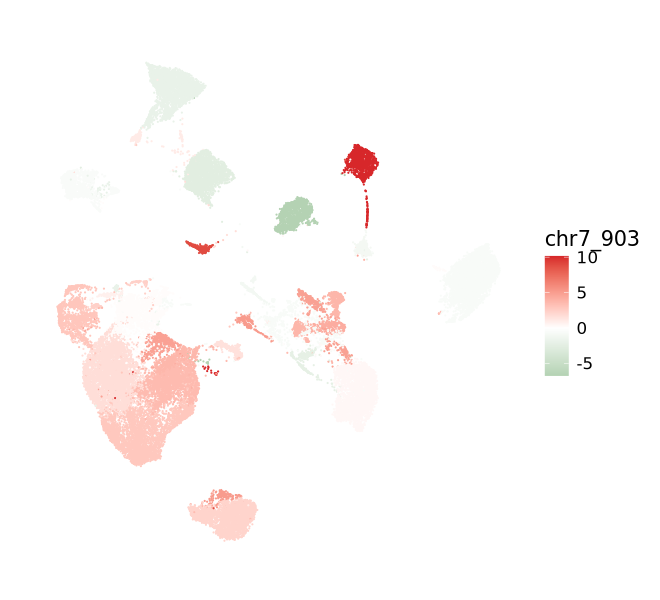

In [42]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2, color = `chr7_903`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#8FBC8F", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)
#     scale_color_gradient2(low = "#8FBC8F", high = "#D7272A")

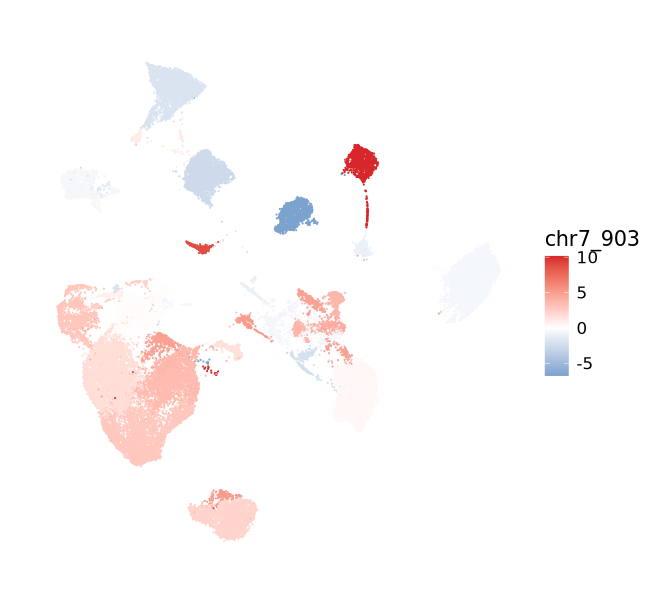

In [43]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2, color = `chr7_903`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#2077B5", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)
#     scale_color_gradient2(low = "#2077B5", high = "#D7272A")

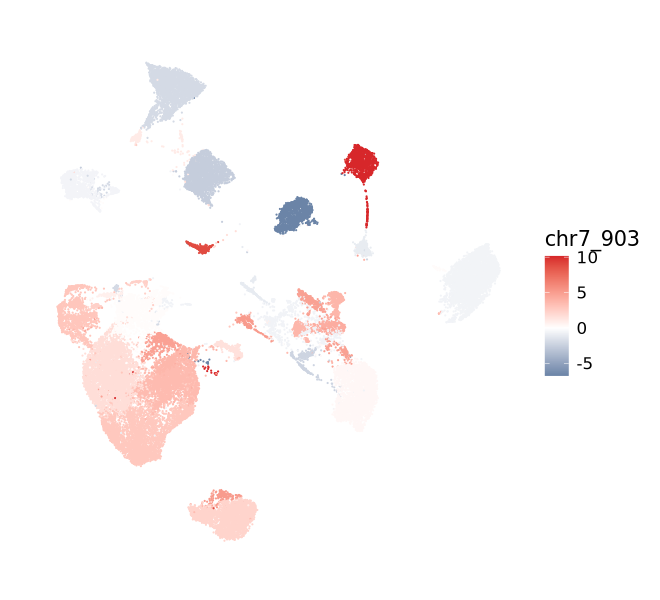

In [44]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2, color = `chr7_903`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#0D4D7D", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)
#     scale_color_gradient2(low = "#2077B5", high = "#D7272A")

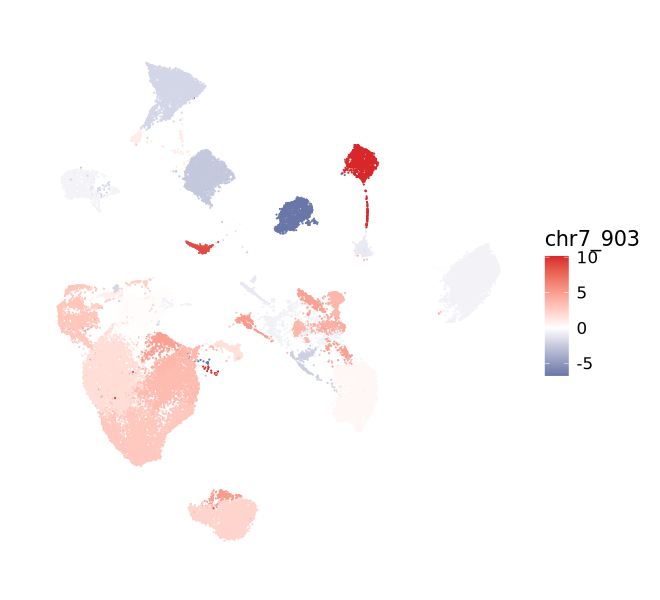

In [45]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2, color = `chr7_903`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#003C7D", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)
#     scale_color_gradient2(low = "#2077B5", high = "#D7272A")

In [46]:
library(scales)

Warning message:
“package ‘scales’ was built under R version 4.3.2”

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




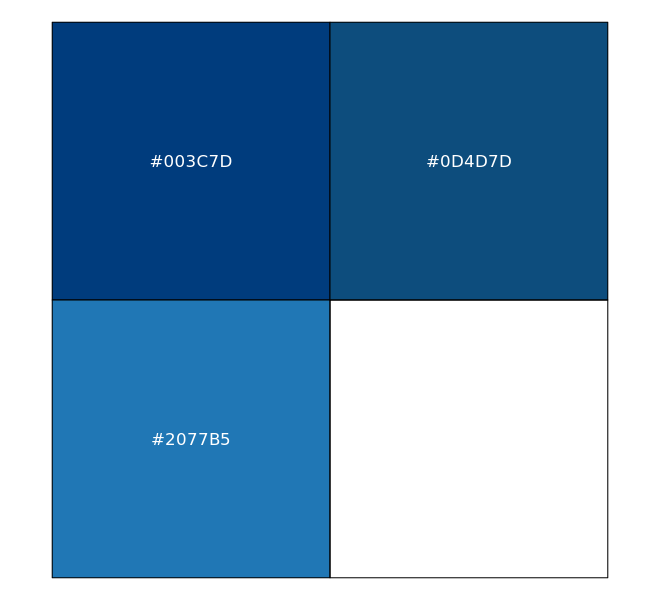

In [47]:
show_col(c("#003C7D","#0D4D7D","#2077B5"))

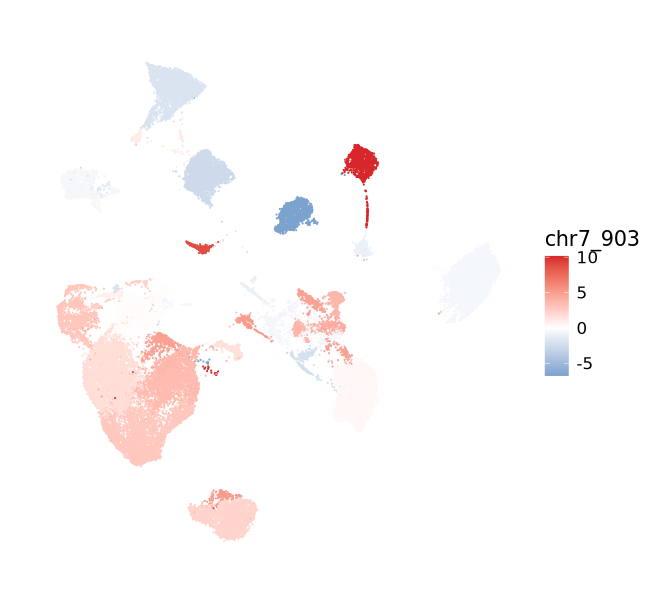

In [48]:
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2, color = `chr7_903`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#2077B5", mid = "#FFFFFF", high = "#D7272A", midpoint = 0, 
                          limits = c(min(UMAP_filter_merged$`chr7_903`), max(UMAP_filter_merged$`chr7_903`)))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-6.7471 -0.5911  1.5443  1.0789  2.8569 10.1465 

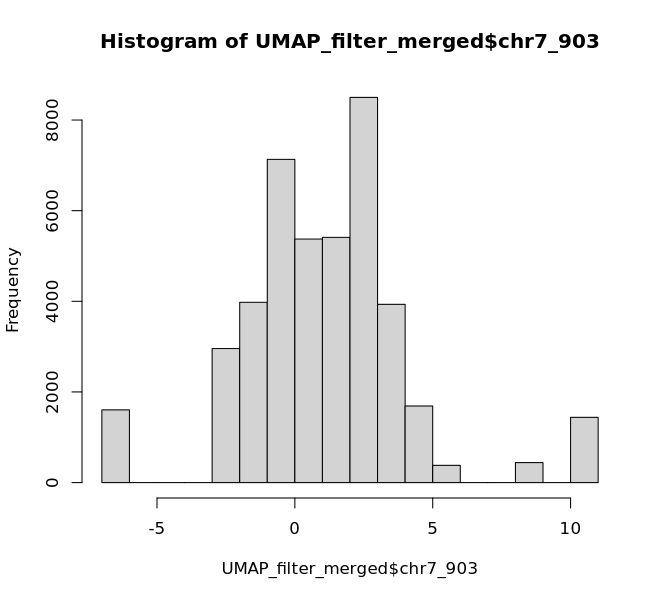

In [49]:
summary(UMAP_filter_merged$chr7_903)
hist(UMAP_filter_merged$chr7_903)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


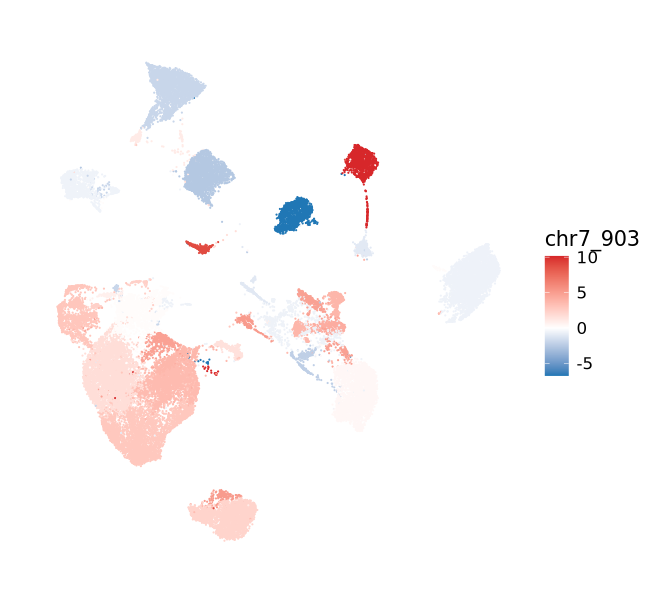

In [50]:
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2)) +
  geom_point(aes(color = `chr7_903`), size = 0.1) +
  labs(x = "", y = "", title = "") +
  theme_minimal() +
  theme(
    text = element_text(size = 15), 
    panel.grid = element_blank(), 
    axis.text = element_blank(),
    axis.ticks = element_blank()
  ) +
  scale_color_gradientn(
    colors = c("#2077B5", "#FFFFFF", "#D7272A"),
    values = scales::rescale(c(min(UMAP_filter_merged$chr7_903), 0, max(UMAP_filter_merged$chr7_903))),
    guide = "colorbar"
  ) +
  scale_color_gradientn(
    colors = c("#2077B5", "#FFFFFF", "#D7272A"),
    values = scales::rescale(c(min(UMAP_filter_merged$chr7_903), 0, max(UMAP_filter_merged$chr7_903)))# ,
#     breaks = c(0)#,
#     labels = c("0")
  ) 

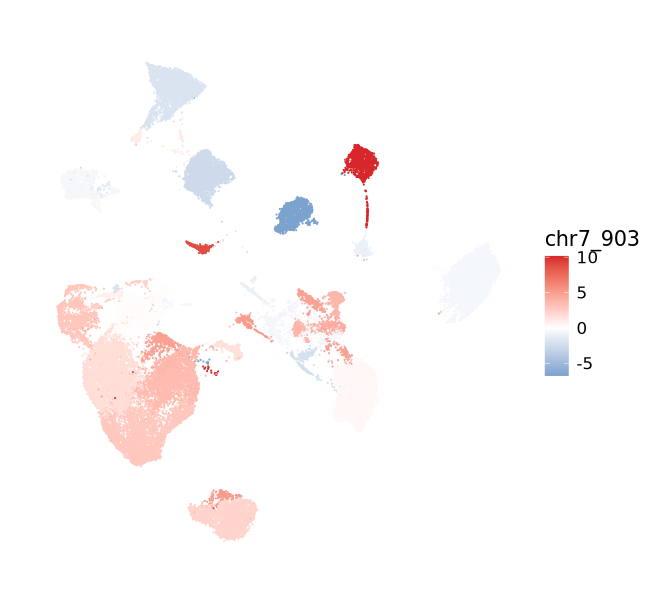

In [51]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2, color = `chr7_903`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#2077B5", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)
#     scale_color_gradient2(low = "#2077B5", high = "#D7272A")

In [52]:
head(UMAP_filter_merged);dim(UMAP_filter_merged)

,umap_1,umap_2,subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-6.1215079,-7.1530786,L4/5 IT CTX Glut,2.856917,1.4888928,5.248351,7.193171,9.741956,7.956738
2,0.3499541,-2.9416876,CLA-EPd-CTX Car3 Glut,1.544318,-3.3054450,-2.146857,9.055837,10.123658,9.637722
3,-7.2109806,0.2295699,L4 RSP-ACA Glut,2.418996,-0.1388017,6.152659,1.992283,2.819330,2.455339
4,-1.3848886,-13.3449722,L6 CT CTX Glut,2.229851,9.5405264,9.853892,11.500115,13.030692,11.896999
5,-6.2881157,-7.7277642,L4/5 IT CTX Glut,2.856917,1.4888928,5.248351,7.193171,9.741956,7.956738
6,-7.8770611,-2.0938309,L2/3 IT RSP Glut,2.959611,5.0539260,6.645447,6.068660,8.787358,7.306526


[1] 42841     9

In [64]:
chrom100k_5hmCG <- read.csv("../output/08-extracted_chr7_903_5hmCG.csv")
chrom100k_5hmCG$cell <- paired_sampleinfo$unique_id[match(chrom100k_5hmCG$cell,paired_sampleinfo$hmC_SampleID)]
colnames(chrom100k_5hmCG)[1] <- "unique_id"
head(chrom100k_5hmCG);dim(chrom100k_5hmCG)

chrom100k_5mCG <- read.csv("../output/08-extracted_chr7_903_5mCG.csv")
chrom100k_5mCG$cell <- paired_sampleinfo$unique_id[match(chrom100k_5mCG$cell,paired_sampleinfo$mC_SampleID)]
colnames(chrom100k_5mCG)[1] <- "unique_id"
head(chrom100k_5mCG);dim(chrom100k_5mCG)

chrom100k_true5mCG <- read.csv("../output/08-extracted_chr7_903_true5mCG.csv")
chrom100k_true5mCG$cell <- paired_sampleinfo$unique_id[match(chrom100k_true5mCG$cell,paired_sampleinfo$mC_SampleID)]
colnames(chrom100k_true5mCG)[1] <- "unique_id"
head(chrom100k_true5mCG);dim(chrom100k_true5mCG)

,unique_id,chr7_903
,<chr>,<dbl>
1,P56_Male_DeepCortex_plate92.GAATCACC,0.2242991
2,P56_Male_DeepCortex_plate92.GAATCCGT,0.3068182
3,P56_Male_DeepCortex_plate92.GACGAACT,0.2372881
4,P56_Male_DeepCortex_plate92.GACGTCAT,0.3114754
5,P56_Male_DeepCortex_plate92.GAGAGTAC,0.0000000
6,P56_Male_DeepCortex_plate92.GATAGCCA,0.2205882


[1] 43075     2

,unique_id,chr7_903
,<chr>,<dbl>
1,P56_Male_Hippo_plate44.CAATGCGA,0.0000000
2,P56_Male_DeepCortex_plate72.GAATCCGT,NA
3,P56_Male_Hippo_plate49.CCAAGGTT,0.8181818
4,P56_Male_Striatum_plate64.CCTTCCAT,NA
5,P56_Male_DeepCortex_plate65.TATGGCAC,0.9655172
6,P56_Male_DeepCortex_plate77.GGCAAGTT,0.8554217


[1] 43075     2

,unique_id,chr7_903
,<chr>,<dbl>
1,P49_Male_LeftCortex_plate1.AACCAGAG,0.5714285
2,P49_Male_LeftCortex_plate1.AAGACACC,NA
3,P49_Male_LeftCortex_plate1.AAGACCGT,0.3273809
4,P49_Male_LeftCortex_plate1.AGACCTTG,0.6558985
5,P49_Male_LeftCortex_plate1.AGACGCTA,NA
6,P49_Male_LeftCortex_plate1.AGCCTATC,0.4943809


[1] 43075     2

In [65]:
paired_sampleinfo_subset <- paired_sampleinfo %>%
  select(unique_id, subclass_label)

In [66]:
head(paired_sampleinfo_subset);dim(paired_sampleinfo_subset)

,unique_id,subclass_label
,<chr>,<chr>
1153,P49_Male_LeftCortex_plate1.AACCAGAG,L4/5 IT CTX Glut
1154,P49_Male_LeftCortex_plate1.AAGACACC,CLA-EPd-CTX Car3 Glut
1155,P49_Male_LeftCortex_plate1.AAGACCGT,L4 RSP-ACA Glut
1156,P49_Male_LeftCortex_plate1.AGACCTTG,L6 CT CTX Glut
1157,P49_Male_LeftCortex_plate1.AGACGCTA,L4/5 IT CTX Glut
1158,P49_Male_LeftCortex_plate1.AGCCTATC,L2/3 IT RSP Glut


[1] 43075     2

In [67]:
head(chrom100k_5hmCG);dim(chrom100k_5hmCG)

,unique_id,chr7_903
,<chr>,<dbl>
1,P56_Male_DeepCortex_plate92.GAATCACC,0.2242991
2,P56_Male_DeepCortex_plate92.GAATCCGT,0.3068182
3,P56_Male_DeepCortex_plate92.GACGAACT,0.2372881
4,P56_Male_DeepCortex_plate92.GACGTCAT,0.3114754
5,P56_Male_DeepCortex_plate92.GAGAGTAC,0.0000000
6,P56_Male_DeepCortex_plate92.GATAGCCA,0.2205882


[1] 43075     2

In [68]:
chrom100k_5hmCG <- chrom100k_5hmCG %>%
  left_join(paired_sampleinfo_subset, by = "unique_id")
head(chrom100k_5hmCG);dim(chrom100k_5hmCG)

,unique_id,chr7_903,subclass_label
,<chr>,<dbl>,<chr>
1,P56_Male_DeepCortex_plate92.GAATCACC,0.2242991,L6 CT CTX Glut
2,P56_Male_DeepCortex_plate92.GAATCCGT,0.3068182,L6 CT CTX Glut
3,P56_Male_DeepCortex_plate92.GACGAACT,0.2372881,L5 IT CTX Glut
4,P56_Male_DeepCortex_plate92.GACGTCAT,0.3114754,Oligo NN
5,P56_Male_DeepCortex_plate92.GAGAGTAC,0.0000000,L5 IT CTX Glut
6,P56_Male_DeepCortex_plate92.GATAGCCA,0.2205882,CA1-ProS Glut


[1] 43075     3

In [69]:
chrom100k_5hmCG <- chrom100k_5hmCG %>%
  group_by(subclass_label) %>%
  mutate(chr7_903 = ifelse(is.na(chr7_903), mean(chr7_903, na.rm = TRUE), chr7_903)) %>%
  ungroup()
head(chrom100k_5hmCG);dim(chrom100k_5hmCG)
table(is.na(chrom100k_5hmCG$chr7_903))

unique_id,chr7_903,subclass_label
<chr>,<dbl>,<chr>
P56_Male_DeepCortex_plate92.GAATCACC,0.2242991,L6 CT CTX Glut
P56_Male_DeepCortex_plate92.GAATCCGT,0.3068182,L6 CT CTX Glut
P56_Male_DeepCortex_plate92.GACGAACT,0.2372881,L5 IT CTX Glut
P56_Male_DeepCortex_plate92.GACGTCAT,0.3114754,Oligo NN
P56_Male_DeepCortex_plate92.GAGAGTAC,0.0000000,L5 IT CTX Glut
P56_Male_DeepCortex_plate92.GATAGCCA,0.2205882,CA1-ProS Glut


[1] 43075     3


FALSE 
43075 

In [71]:
chrom100k_5mCG <- chrom100k_5mCG %>%
  left_join(paired_sampleinfo_subset, by = "unique_id")
head(chrom100k_5mCG);dim(chrom100k_5mCG)

chrom100k_true5mCG <- chrom100k_true5mCG %>%
  left_join(paired_sampleinfo_subset, by = "unique_id")
head(chrom100k_true5mCG);dim(chrom100k_true5mCG)

,unique_id,chr7_903,subclass_label
,<chr>,<dbl>,<chr>
1,P56_Male_Hippo_plate44.CAATGCGA,0.0000000,L2/3 IT RSP Glut
2,P56_Male_DeepCortex_plate72.GAATCCGT,NA,L2/3 IT CTX Glut
3,P56_Male_Hippo_plate49.CCAAGGTT,0.8181818,L2/3 IT RSP Glut
4,P56_Male_Striatum_plate64.CCTTCCAT,NA,STR D1 Gaba
5,P56_Male_DeepCortex_plate65.TATGGCAC,0.9655172,L5 NP CTX Glut
6,P56_Male_DeepCortex_plate77.GGCAAGTT,0.8554217,L5 IT CTX Glut


[1] 43075     3

,unique_id,chr7_903,subclass_label
,<chr>,<dbl>,<chr>
1,P49_Male_LeftCortex_plate1.AACCAGAG,0.5714285,L4/5 IT CTX Glut
2,P49_Male_LeftCortex_plate1.AAGACACC,NA,CLA-EPd-CTX Car3 Glut
3,P49_Male_LeftCortex_plate1.AAGACCGT,0.3273809,L4 RSP-ACA Glut
4,P49_Male_LeftCortex_plate1.AGACCTTG,0.6558985,L6 CT CTX Glut
5,P49_Male_LeftCortex_plate1.AGACGCTA,NA,L4/5 IT CTX Glut
6,P49_Male_LeftCortex_plate1.AGCCTATC,0.4943809,L2/3 IT RSP Glut


[1] 43075     3

In [72]:
chrom100k_5mCG <- chrom100k_5mCG %>%
  group_by(subclass_label) %>%
  mutate(chr7_903 = ifelse(is.na(chr7_903), mean(chr7_903, na.rm = TRUE), chr7_903)) %>%
  ungroup()
head(chrom100k_5mCG);dim(chrom100k_5mCG)
table(is.na(chrom100k_5mCG$chr7_903))

chrom100k_true5mCG <- chrom100k_true5mCG %>%
  group_by(subclass_label) %>%
  mutate(chr7_903 = ifelse(is.na(chr7_903), mean(chr7_903, na.rm = TRUE), chr7_903)) %>%
  ungroup()
head(chrom100k_true5mCG);dim(chrom100k_true5mCG)
table(is.na(chrom100k_true5mCG$chr7_903))

unique_id,chr7_903,subclass_label
<chr>,<dbl>,<chr>
P56_Male_Hippo_plate44.CAATGCGA,0.0000000,L2/3 IT RSP Glut
P56_Male_DeepCortex_plate72.GAATCCGT,0.7868290,L2/3 IT CTX Glut
P56_Male_Hippo_plate49.CCAAGGTT,0.8181818,L2/3 IT RSP Glut
P56_Male_Striatum_plate64.CCTTCCAT,0.8518869,STR D1 Gaba
P56_Male_DeepCortex_plate65.TATGGCAC,0.9655172,L5 NP CTX Glut
P56_Male_DeepCortex_plate77.GGCAAGTT,0.8554217,L5 IT CTX Glut


[1] 43075     3


FALSE 
43075 

unique_id,chr7_903,subclass_label
<chr>,<dbl>,<chr>
P49_Male_LeftCortex_plate1.AACCAGAG,0.5714285,L4/5 IT CTX Glut
P49_Male_LeftCortex_plate1.AAGACACC,0.5027055,CLA-EPd-CTX Car3 Glut
P49_Male_LeftCortex_plate1.AAGACCGT,0.3273809,L4 RSP-ACA Glut
P49_Male_LeftCortex_plate1.AGACCTTG,0.6558985,L6 CT CTX Glut
P49_Male_LeftCortex_plate1.AGACGCTA,0.5304712,L4/5 IT CTX Glut
P49_Male_LeftCortex_plate1.AGCCTATC,0.4943809,L2/3 IT RSP Glut


[1] 43075     3


FALSE 
43075 

In [73]:
head(UMAP_filter_merged);dim(UMAP_filter_merged)

,umap_1,umap_2,subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-6.1215079,-7.1530786,L4/5 IT CTX Glut,2.856917,1.4888928,5.248351,7.193171,9.741956,7.956738
2,0.3499541,-2.9416876,CLA-EPd-CTX Car3 Glut,1.544318,-3.3054450,-2.146857,9.055837,10.123658,9.637722
3,-7.2109806,0.2295699,L4 RSP-ACA Glut,2.418996,-0.1388017,6.152659,1.992283,2.819330,2.455339
4,-1.3848886,-13.3449722,L6 CT CTX Glut,2.229851,9.5405264,9.853892,11.500115,13.030692,11.896999
5,-6.2881157,-7.7277642,L4/5 IT CTX Glut,2.856917,1.4888928,5.248351,7.193171,9.741956,7.956738
6,-7.8770611,-2.0938309,L2/3 IT RSP Glut,2.959611,5.0539260,6.645447,6.068660,8.787358,7.306526


[1] 42841     9

In [74]:
identical(UMAP_filter_merged$umap_1,UMAP_filter$umap_1)

[1] TRUE

In [75]:
rownames(UMAP_filter_merged) <- NULL
rownames(UMAP_filter_merged) <- rownames(UMAP_filter)
head(UMAP_filter_merged);dim(UMAP_filter_merged)

,umap_1,umap_2,subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P49_Male_LeftCortex_TSO_RNA_plate1.AACCAGAG,-6.1215079,-7.1530786,L4/5 IT CTX Glut,2.856917,1.4888928,5.248351,7.193171,9.741956,7.956738
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACACC,0.3499541,-2.9416876,CLA-EPd-CTX Car3 Glut,1.544318,-3.3054450,-2.146857,9.055837,10.123658,9.637722
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACCGT,-7.2109806,0.2295699,L4 RSP-ACA Glut,2.418996,-0.1388017,6.152659,1.992283,2.819330,2.455339
P49_Male_LeftCortex_TSO_RNA_plate1.AGACCTTG,-1.3848886,-13.3449722,L6 CT CTX Glut,2.229851,9.5405264,9.853892,11.500115,13.030692,11.896999
P49_Male_LeftCortex_TSO_RNA_plate1.AGACGCTA,-6.2881157,-7.7277642,L4/5 IT CTX Glut,2.856917,1.4888928,5.248351,7.193171,9.741956,7.956738
P49_Male_LeftCortex_TSO_RNA_plate1.AGCCTATC,-7.8770611,-2.0938309,L2/3 IT RSP Glut,2.959611,5.0539260,6.645447,6.068660,8.787358,7.306526


[1] 42841     9

In [76]:
table(rownames(UMAP_filter_merged) %in% paired_sampleinfo$RNA_SampleID)


 TRUE 
42841 

In [77]:
rownames(UMAP_filter_merged) <- paired_sampleinfo$unique_id[match(rownames(UMAP_filter_merged),paired_sampleinfo$RNA_SampleID)]
head(UMAP_filter_merged);dim(UMAP_filter_merged)

,umap_1,umap_2,subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P49_Male_LeftCortex_plate1.AACCAGAG,-6.1215079,-7.1530786,L4/5 IT CTX Glut,2.856917,1.4888928,5.248351,7.193171,9.741956,7.956738
P49_Male_LeftCortex_plate1.AAGACACC,0.3499541,-2.9416876,CLA-EPd-CTX Car3 Glut,1.544318,-3.3054450,-2.146857,9.055837,10.123658,9.637722
P49_Male_LeftCortex_plate1.AAGACCGT,-7.2109806,0.2295699,L4 RSP-ACA Glut,2.418996,-0.1388017,6.152659,1.992283,2.819330,2.455339
P49_Male_LeftCortex_plate1.AGACCTTG,-1.3848886,-13.3449722,L6 CT CTX Glut,2.229851,9.5405264,9.853892,11.500115,13.030692,11.896999
P49_Male_LeftCortex_plate1.AGACGCTA,-6.2881157,-7.7277642,L4/5 IT CTX Glut,2.856917,1.4888928,5.248351,7.193171,9.741956,7.956738
P49_Male_LeftCortex_plate1.AGCCTATC,-7.8770611,-2.0938309,L2/3 IT RSP Glut,2.959611,5.0539260,6.645447,6.068660,8.787358,7.306526


[1] 42841     9

In [78]:
UMAP_filter_chr7_903 <- UMAP_filter_merged[,c("umap_1","umap_2","subclass","chr7_903")]
colnames(UMAP_filter_chr7_903) <- c("umap_1","umap_2","subclass","Compartment score")
head(UMAP_filter_chr7_903);dim(UMAP_filter_chr7_903)

,umap_1,umap_2,subclass,Compartment score
,<dbl>,<dbl>,<chr>,<dbl>
P49_Male_LeftCortex_plate1.AACCAGAG,-6.1215079,-7.1530786,L4/5 IT CTX Glut,2.856917
P49_Male_LeftCortex_plate1.AAGACACC,0.3499541,-2.9416876,CLA-EPd-CTX Car3 Glut,1.544318
P49_Male_LeftCortex_plate1.AAGACCGT,-7.2109806,0.2295699,L4 RSP-ACA Glut,2.418996
P49_Male_LeftCortex_plate1.AGACCTTG,-1.3848886,-13.3449722,L6 CT CTX Glut,2.229851
P49_Male_LeftCortex_plate1.AGACGCTA,-6.2881157,-7.7277642,L4/5 IT CTX Glut,2.856917
P49_Male_LeftCortex_plate1.AGCCTATC,-7.8770611,-2.0938309,L2/3 IT RSP Glut,2.959611


[1] 42841     4

In [79]:
UMAP_filter_chr7_903$`5hmCG` <- chrom100k_5hmCG$chr7_903[match(rownames(UMAP_filter_chr7_903),chrom100k_5hmCG$unique_id)]
UMAP_filter_chr7_903$`5hmCG+5mCG` <- chrom100k_5mCG$chr7_903[match(rownames(UMAP_filter_chr7_903),chrom100k_5mCG$unique_id)]
UMAP_filter_chr7_903$`5mCG` <- chrom100k_true5mCG$chr7_903[match(rownames(UMAP_filter_chr7_903),chrom100k_true5mCG$unique_id)]

In [80]:
head(UMAP_filter_chr7_903);dim(UMAP_filter_chr7_903)

,umap_1,umap_2,subclass,Compartment score,5hmCG,5hmCG+5mCG,5mCG
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
P49_Male_LeftCortex_plate1.AACCAGAG,-6.1215079,-7.1530786,L4/5 IT CTX Glut,2.856917,0.4285714,1.0000000,0.5714285
P49_Male_LeftCortex_plate1.AAGACACC,0.3499541,-2.9416876,CLA-EPd-CTX Car3 Glut,1.544318,0.2879530,0.7899736,0.5027055
P49_Male_LeftCortex_plate1.AAGACCGT,-7.2109806,0.2295699,L4 RSP-ACA Glut,2.418996,0.3333333,0.6607143,0.3273809
P49_Male_LeftCortex_plate1.AGACCTTG,-1.3848886,-13.3449722,L6 CT CTX Glut,2.229851,0.1413043,0.7972028,0.6558985
P49_Male_LeftCortex_plate1.AGACGCTA,-6.2881157,-7.7277642,L4/5 IT CTX Glut,2.856917,0.2530953,0.7838872,0.5304712
P49_Male_LeftCortex_plate1.AGCCTATC,-7.8770611,-2.0938309,L2/3 IT RSP Glut,2.959611,0.2976190,0.7920000,0.4943809


[1] 42841     7

In [81]:
UMAP_filter_chr7_903[["5hmCG"]] <- pmin(pmax(UMAP_filter_chr7_903[["5hmCG"]], 0.2), 0.5)

In [82]:
p2 <- ggplot(UMAP_filter_chr7_903[,c("umap_1","umap_2","5hmCG")], aes(x = umap_1, y = umap_2, color = `5hmCG`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = c(0.2, 0.5), breaks = c(0.2, 0.5))

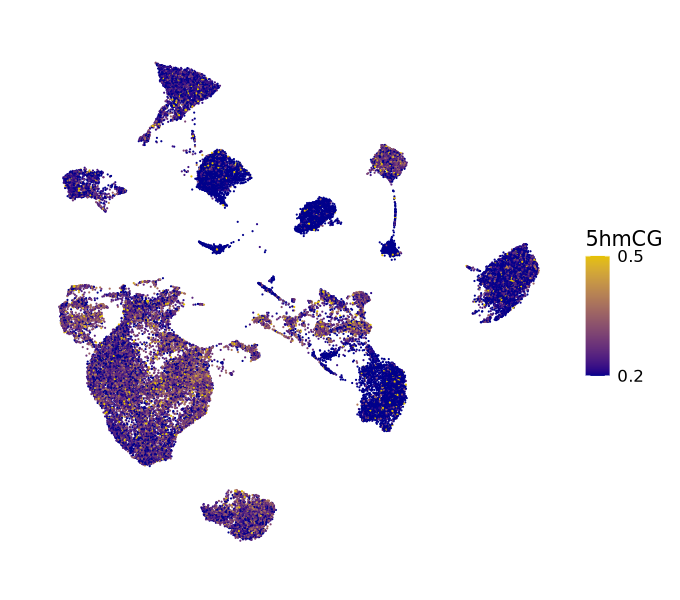

In [83]:
options(repr.plot.width = 6.8, repr.plot.height = 6, repr.plot.res = 100)
p2

In [84]:
UMAP_filter_chr7_903[["5hmCG+5mCG"]] <- pmin(pmax(UMAP_filter_chr7_903[["5hmCG+5mCG"]], 0.3), 1)

In [85]:
p3 <- ggplot(UMAP_filter_chr7_903[,c("umap_1","umap_2","5hmCG+5mCG")], aes(x = umap_1, y = umap_2, color = `5hmCG+5mCG`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = c(0.3, 1), breaks = c(0.3, 1))

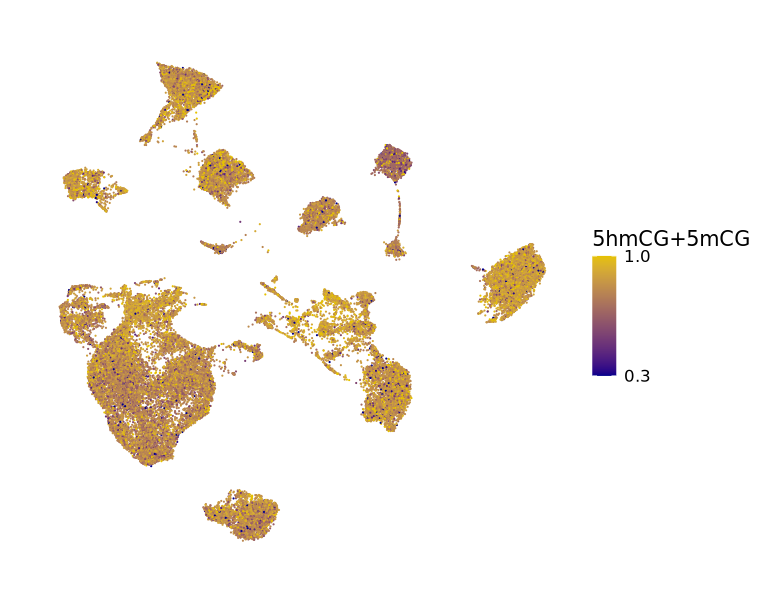

In [86]:
options(repr.plot.width = 7.7, repr.plot.height = 6, repr.plot.res = 100)
p3

In [87]:
UMAP_filter_chr7_903[["5mCG"]] <- pmin(pmax(UMAP_filter_chr7_903[["5mCG"]], 0.3), 0.8)

In [88]:
p4 <- ggplot(UMAP_filter_chr7_903[,c("umap_1","umap_2","5mCG")], aes(x = umap_1, y = umap_2, color = `5mCG`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = c(0.3, 0.8), breaks = c(0.3, 0.8))

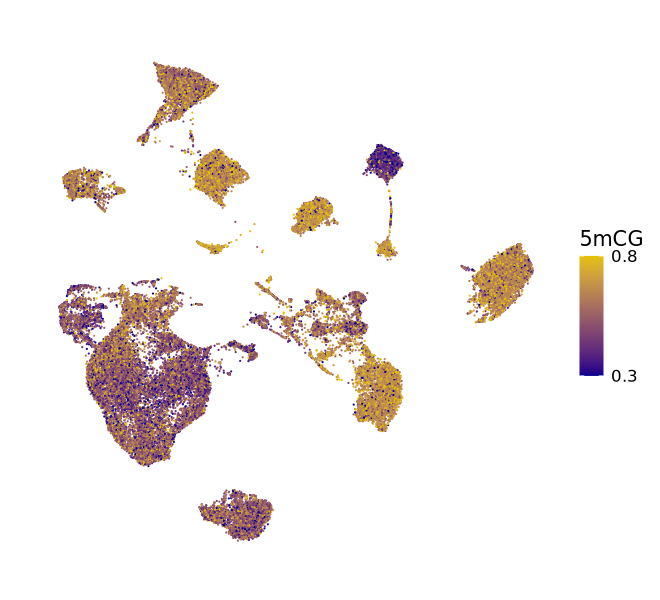

In [89]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
p4

In [90]:
p1 <- ggplot(UMAP_filter_chr7_903, aes(x = umap_1, y = umap_2)) +
  geom_point(aes(color = `Compartment score`), size = 0.1) +
  labs(x = "", y = "", title = "") +
  theme_minimal() +
  theme(
    text = element_text(size = 15), 
    panel.grid = element_blank(), 
    axis.text = element_blank(),
    axis.ticks = element_blank()
  ) +
  scale_color_gradientn(
    colors = c("#2077B5", "#FFFFFF", "#D7272A"),
    values = scales::rescale(c(min(UMAP_filter_merged$chr7_903), 0, max(UMAP_filter_merged$chr7_903))),
    guide = "colorbar"
  ) +
  scale_color_gradientn(
    colors = c("#2077B5", "#FFFFFF", "#D7272A"),
    values = scales::rescale(c(min(UMAP_filter_merged$chr7_903), 0, max(UMAP_filter_merged$chr7_903)))# ,
#     breaks = c(0)#,
#     labels = c("0")
  ) 

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


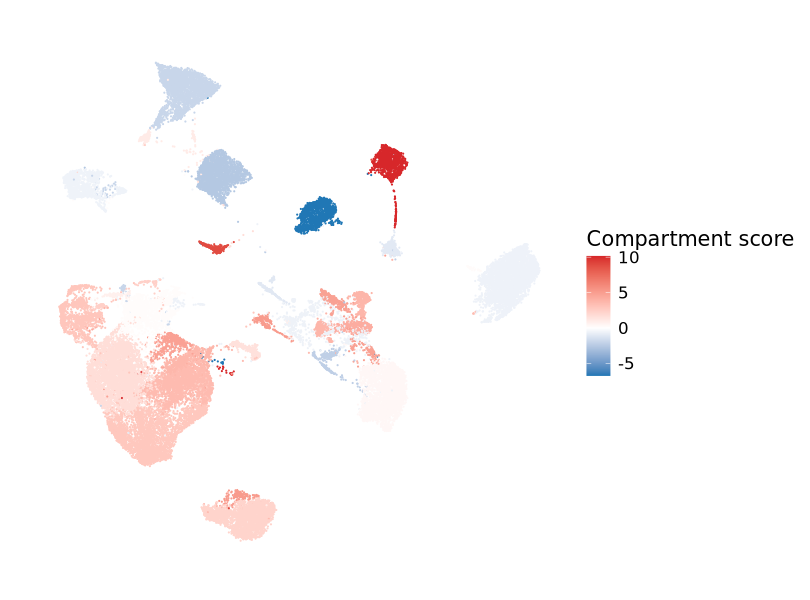

In [91]:
options(repr.plot.width = 8.1, repr.plot.height = 6, repr.plot.res = 100)
p1

In [92]:
library(gridExtra)
library(ggplot2)


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [93]:
gpp1 <- arrangeGrob(p1, heights = unit(6, "inches"), widths = unit(8.1, "inches"))
gpp2 <- arrangeGrob(p2, heights = unit(6, "inches"), widths = unit(6.8, "inches"))
gpp3 <- arrangeGrob(p3, heights = unit(6, "inches"), widths = unit(7.7, "inches"))
gpp4 <- arrangeGrob(p4, heights = unit(6, "inches"), widths = unit(6.6, "inches"))

In [94]:
combined_plot <- arrangeGrob(gpp1, gpp2, gpp3, gpp4, ncol = 4, nrow = 1)

In [ ]:
ggsave("../output/09-UMAP_chr7_903_show_3C_DNA_methyl_including_non_neuron.pdf", 
       combined_plot, 
       width = 32, height = 6)

In [ ]:
chrom100k_5hmCG <- read.csv("../output/08-extracted_chr7_903_5hmCG.csv")
chrom100k_5hmCG$cell <- paired_sampleinfo$unique_id[match(chrom100k_5hmCG$cell,paired_sampleinfo$hmC_SampleID)]
colnames(chrom100k_5hmCG)[1] <- "unique_id"
head(chrom100k_5hmCG);dim(chrom100k_5hmCG)

chrom100k_5mCG <- read.csv("../output/08-extracted_chr7_903_5mCG.csv")
chrom100k_5mCG$cell <- paired_sampleinfo$unique_id[match(chrom100k_5mCG$cell,paired_sampleinfo$mC_SampleID)]
colnames(chrom100k_5mCG)[1] <- "unique_id"
head(chrom100k_5mCG);dim(chrom100k_5mCG)

chrom100k_true5mCG <- read.csv("../output/08-extracted_chr7_903_true5mCG.csv")
chrom100k_true5mCG$cell <- paired_sampleinfo$unique_id[match(chrom100k_true5mCG$cell,paired_sampleinfo$mC_SampleID)]
colnames(chrom100k_true5mCG)[1] <- "unique_id"
head(chrom100k_true5mCG);dim(chrom100k_true5mCG)

In [96]:
head(UMAP_filter_merged);dim(UMAP_filter_merged)

,umap_1,umap_2,subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P49_Male_LeftCortex_plate1.AACCAGAG,-6.1215079,-7.1530786,L4/5 IT CTX Glut,2.856917,1.4888928,5.248351,7.193171,9.741956,7.956738
P49_Male_LeftCortex_plate1.AAGACACC,0.3499541,-2.9416876,CLA-EPd-CTX Car3 Glut,1.544318,-3.3054450,-2.146857,9.055837,10.123658,9.637722
P49_Male_LeftCortex_plate1.AAGACCGT,-7.2109806,0.2295699,L4 RSP-ACA Glut,2.418996,-0.1388017,6.152659,1.992283,2.819330,2.455339
P49_Male_LeftCortex_plate1.AGACCTTG,-1.3848886,-13.3449722,L6 CT CTX Glut,2.229851,9.5405264,9.853892,11.500115,13.030692,11.896999
P49_Male_LeftCortex_plate1.AGACGCTA,-6.2881157,-7.7277642,L4/5 IT CTX Glut,2.856917,1.4888928,5.248351,7.193171,9.741956,7.956738
P49_Male_LeftCortex_plate1.AGCCTATC,-7.8770611,-2.0938309,L2/3 IT RSP Glut,2.959611,5.0539260,6.645447,6.068660,8.787358,7.306526


[1] 42841     9

In [103]:
process_chrom_column <- function(column_name, UMAP_filter_merged, paired_sampleinfo, output_dir, range_5hmCG = c(0.2, 0.5), range_5hmCG_5mCG = c(0.3, 1), range_5mCG = c(0.3, 1)) {

  chrom_5hmCG <- read.csv(paste0(output_dir, "/08-extracted_", column_name, "_5hmCG.csv"))
  chrom_5hmCG$cell <- paired_sampleinfo$unique_id[match(chrom_5hmCG$cell,paired_sampleinfo$hmC_SampleID)]
  colnames(chrom_5hmCG)[1] <- "unique_id"
  chrom_5mCG <- read.csv(paste0(output_dir, "/08-extracted_", column_name, "_5mCG.csv"))
  chrom_5mCG$cell <- paired_sampleinfo$unique_id[match(chrom_5mCG$cell,paired_sampleinfo$mC_SampleID)]
  colnames(chrom_5mCG)[1] <- "unique_id"
  chrom_true5mCG <- read.csv(paste0(output_dir, "/08-extracted_", column_name, "_true5mCG.csv"))
  chrom_true5mCG$cell <- paired_sampleinfo$unique_id[match(chrom_true5mCG$cell,paired_sampleinfo$mC_SampleID)]
  colnames(chrom_true5mCG)[1] <- "unique_id"

  paired_sampleinfo_subset <- paired_sampleinfo %>% select(unique_id, subclass_label)

  chrom_5hmCG <- chrom_5hmCG %>% left_join(paired_sampleinfo_subset, by = "unique_id")
  chrom_5mCG <- chrom_5mCG %>% left_join(paired_sampleinfo_subset, by = "unique_id")
  chrom_true5mCG <- chrom_true5mCG %>% left_join(paired_sampleinfo_subset, by = "unique_id")

  chrom_5hmCG <- chrom_5hmCG %>% group_by(subclass_label) %>% mutate(!!column_name := ifelse(is.na(!!sym(column_name)), mean(!!sym(column_name), na.rm = TRUE), !!sym(column_name))) %>% ungroup()
  chrom_5mCG <- chrom_5mCG %>% group_by(subclass_label) %>% mutate(!!column_name := ifelse(is.na(!!sym(column_name)), mean(!!sym(column_name), na.rm = TRUE), !!sym(column_name))) %>% ungroup()
  chrom_true5mCG <- chrom_true5mCG %>% group_by(subclass_label) %>% mutate(!!column_name := ifelse(is.na(!!sym(column_name)), mean(!!sym(column_name), na.rm = TRUE), !!sym(column_name))) %>% ungroup()

  UMAP_filter_column <- UMAP_filter_merged[, c("umap_1", "umap_2", "subclass", column_name)]
  colnames(UMAP_filter_column) <- c("umap_1", "umap_2", "subclass", "Compartment score")

  UMAP_filter_column$`5hmCG` <- chrom_5hmCG[[column_name]][match(rownames(UMAP_filter_column), chrom_5hmCG$unique_id)]
  UMAP_filter_column$`5hmCG+5mCG` <- chrom_5mCG[[column_name]][match(rownames(UMAP_filter_column), chrom_5mCG$unique_id)]
  UMAP_filter_column$`5mCG` <- chrom_true5mCG[[column_name]][match(rownames(UMAP_filter_column), chrom_true5mCG$unique_id)]

  UMAP_filter_column[["5hmCG"]] <- pmin(pmax(UMAP_filter_column[["5hmCG"]], range_5hmCG[1]), range_5hmCG[2])
  UMAP_filter_column[["5hmCG+5mCG"]] <- pmin(pmax(UMAP_filter_column[["5hmCG+5mCG"]], range_5hmCG_5mCG[1]), range_5hmCG_5mCG[2])
  UMAP_filter_column[["5mCG"]] <- pmin(pmax(UMAP_filter_column[["5mCG"]], range_5mCG[1]), range_5mCG[2])

  p1 <- ggplot(UMAP_filter_column, aes(x = umap_1, y = umap_2)) +
    geom_point(aes(color = `Compartment score`), size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(
      text = element_text(size = 15),
      panel.grid = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    ) +
    scale_color_gradientn(
      colors = c("#2077B5", "#FFFFFF", "#D7272A"),
      values = scales::rescale(c(min(UMAP_filter_merged[[column_name]]), 0, max(UMAP_filter_merged[[column_name]]))),
      guide = "colorbar"
    )
  
  p2 <- ggplot(UMAP_filter_column, aes(x = umap_1, y = umap_2, color = `5hmCG`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = range_5hmCG, breaks = range_5hmCG)
  
  p3 <- ggplot(UMAP_filter_column, aes(x = umap_1, y = umap_2, color = `5hmCG+5mCG`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = range_5hmCG_5mCG, breaks = range_5hmCG_5mCG)
  
  p4 <- ggplot(UMAP_filter_column, aes(x = umap_1, y = umap_2, color = `5mCG`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = range_5mCG, breaks = range_5mCG)

  library(gridExtra)
  gpp1 <- arrangeGrob(p1, heights = unit(6, "inches"), widths = unit(8.1, "inches"))
  gpp2 <- arrangeGrob(p2, heights = unit(6, "inches"), widths = unit(6.8, "inches"))
  gpp3 <- arrangeGrob(p3, heights = unit(6, "inches"), widths = unit(7.7, "inches"))
  gpp4 <- arrangeGrob(p4, heights = unit(6, "inches"), widths = unit(6.6, "inches"))
  
  combined_plot <- arrangeGrob(gpp1, gpp2, gpp3, gpp4, ncol = 4, nrow = 1)

  ggsave(paste0(output_dir, "/09-UMAP_", column_name, "_show_3C_DNA_methyl_including_non_neuron.pdf"), 
         combined_plot, width = 32, height = 6)
}

In [98]:
head(UMAP_filter_merged);dim(UMAP_filter_merged)

,umap_1,umap_2,subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P49_Male_LeftCortex_plate1.AACCAGAG,-6.1215079,-7.1530786,L4/5 IT CTX Glut,2.856917,1.4888928,5.248351,7.193171,9.741956,7.956738
P49_Male_LeftCortex_plate1.AAGACACC,0.3499541,-2.9416876,CLA-EPd-CTX Car3 Glut,1.544318,-3.3054450,-2.146857,9.055837,10.123658,9.637722
P49_Male_LeftCortex_plate1.AAGACCGT,-7.2109806,0.2295699,L4 RSP-ACA Glut,2.418996,-0.1388017,6.152659,1.992283,2.819330,2.455339
P49_Male_LeftCortex_plate1.AGACCTTG,-1.3848886,-13.3449722,L6 CT CTX Glut,2.229851,9.5405264,9.853892,11.500115,13.030692,11.896999
P49_Male_LeftCortex_plate1.AGACGCTA,-6.2881157,-7.7277642,L4/5 IT CTX Glut,2.856917,1.4888928,5.248351,7.193171,9.741956,7.956738
P49_Male_LeftCortex_plate1.AGCCTATC,-7.8770611,-2.0938309,L2/3 IT RSP Glut,2.959611,5.0539260,6.645447,6.068660,8.787358,7.306526


[1] 42841     9

In [104]:
process_chrom_column(
  column_name = "chr5_201", 
  UMAP_filter_merged = UMAP_filter_merged, 
  paired_sampleinfo = paired_sampleinfo, 
  output_dir = "../output/",
  range_5hmCG = c(0.2, 0.5),
  range_5hmCG_5mCG = c(0.3, 1),
  range_5mCG = c(0.3, 0.8)
)

In [105]:
process_chrom_column(
  column_name = "chr2_390", 
  UMAP_filter_merged = UMAP_filter_merged, 
  paired_sampleinfo = paired_sampleinfo, 
  output_dir = "../output/",
  range_5hmCG = c(0.2, 0.5),
  range_5hmCG_5mCG = c(0.3, 1),
  range_5mCG = c(0.3, 0.8)
)

In [106]:
process_chrom_column(
  column_name = "chr8_173", 
  UMAP_filter_merged = UMAP_filter_merged, 
  paired_sampleinfo = paired_sampleinfo, 
  output_dir = "../output/",
  range_5hmCG = c(0.2, 0.5),
  range_5hmCG_5mCG = c(0.3, 1),
  range_5mCG = c(0.3, 0.8)
)

In [107]:
## 0.3-1
process_chrom_column(
  column_name = "chr8_171", 
  UMAP_filter_merged = UMAP_filter_merged, 
  paired_sampleinfo = paired_sampleinfo, 
  output_dir = "../output/",
  range_5hmCG = c(0.2, 0.5),
  range_5hmCG_5mCG = c(0.3, 1),
  range_5mCG = c(0.3, 1)
)

In [108]:
## 0.4-1
process_chrom_column(
  column_name = "chr8_171", 
  UMAP_filter_merged = UMAP_filter_merged, 
  paired_sampleinfo = paired_sampleinfo, 
  output_dir = "../output/",
  range_5hmCG = c(0.2, 0.5),
  range_5hmCG_5mCG = c(0.4, 1),
  range_5mCG = c(0.4, 1)
)

In [109]:
process_chrom_column(
  column_name = "chr8_172", 
  UMAP_filter_merged = UMAP_filter_merged, 
  paired_sampleinfo = paired_sampleinfo, 
  output_dir = "../output/",
  range_5hmCG = c(0.2, 0.5),
  range_5hmCG_5mCG = c(0.3, 1),
  range_5mCG = c(0.3, 0.8)
)